Hey! this is your space to plot rates and efficiencies ;)

In [5]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis')

from libs import crudo

from iminuit import Minuit
from iminuit.cost import LeastSquares
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from PIL import Image
import scipy
import yaml

# Styling Plot
crudo.pt.ccortesp_plot_style()
PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Configuration

In [28]:
# --- NOTEBOOK PARAMETERS --- #
VERSION_TAG = "LPR_p2_v2"
ANA_OPTIONS =  ['data']
ANA_INFO = {opt:{} for opt in ANA_OPTIONS }

RATES_INFO_COLS = ['Run_ID', 'Duration', 'Date_CV', 'Date_Err', 'OK', 'LOST', 'Sophronia', 'Fiducial']

# Important Dates
# Period 01
CPC_RAS = 1746791100      # Castle = partially closed & RAS = on
CPC     = 1747042200      # Castle = partially closed & RAS = off
CC_RAS  = 1749024786      # Castle = closed & RAS = on
# Period 02
CC_02      = 1753092000   # Castle = closed & RAS = off
CC_RAS_02  = 1754035200   # Castle = closed & RAS = on

# Special Dates
SEP_2025 = 1756764000     # 2nd September 2025

In [29]:
# -------------------
# LOAD CONFIGURATIONS
# -------------------
CONFIG_FILE = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Universal/configs/low_bckg_analysis_config.yaml'

try:
    with open(CONFIG_FILE, 'r') as f:
        all_configs = yaml.safe_load(f)
except FileNotFoundError:
    raise FileNotFoundError(f"Configuration file '{CONFIG_FILE}' not found. Please check the path and try again.")

if VERSION_TAG not in all_configs:
    raise ValueError(f"Version tag '{VERSION_TAG}' not found in the configuration file. Available tags: {list(all_configs.keys())}")

# Set up the configuration
common_config = all_configs['common']
ana_config    = all_configs[VERSION_TAG]

for ana_type in ANA_OPTIONS:
    if ana_type in ana_config:
        print(f"{'-'*5} Loading configuration for {ana_type.upper()}")

        # Load directories and paths
        runs_info_path = common_config['runs_info']
        summary_dir = common_config['summary_dir']
        summary_path = os.path.join(summary_dir, ana_config[ana_type]['summary_file']).replace('processed', 'updated')
        print(f"  Runs info path   : {runs_info_path}")
        print(f"  Summary file path : {summary_path}")

        # Load dataframes
        df_runs_info = pd.read_csv(runs_info_path)
        df_runs_info.columns = df_runs_info.columns.str.strip()  
        df_summary = pd.read_csv(summary_path)
        df_summary.drop(columns=['Unnamed: 0'], inplace=True)
        df_summary.columns = df_summary.columns.str.strip()

        # Store information
        ANA_INFO[ana_type] = { 'df_runs_info' : df_runs_info
                             , 'df_summary'   : df_summary
                             , 'period'       : ana_config[ana_type]['extra']['period']
                             , 'det_cond'     : ana_config[ana_type]['extra']['det_cond']}

        print(f"Loaded successfully.\n")

----- Loading configuration for DATA
  Runs info path   : /lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/utilities/runs_information.csv
  Summary file path : /lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/summaries/summary_p2_zemrude_v2_updated.csv
Loaded successfully.



### Construct Rates Dataframe

__WE NEED TO RE-THINK THIS!__

In [27]:
# selection_mask = pd.Series(True, index=RUNS_INFO_DF.index)

# runs_in_summary = SUMMARY_DF['Run_ID'].unique()
# print(f"→ Must be one of the {len(runs_in_summary)} runs in the summary")
# selection_mask &= RUNS_INFO_DF['run_number'].isin(runs_in_summary)

# if DATA_PERIOD is not None:
#     print(f"→ Period == {DATA_PERIOD}")
#     # The '&=' operator is a shortcut for 'selection_mask = selection_mask & ...'
#     selection_mask &= (RUNS_INFO_DF['period'] == DATA_PERIOD)

# if DETECTOR_CONDITION is not None:
#     print(f"→ Condition == '{DETECTOR_CONDITION}'")
#     selection_mask &= (RUNS_INFO_DF['condition'] == DETECTOR_CONDITION)

# RUNS_TO_ANALYZE = RUNS_INFO_DF.loc[selection_mask, 'run_number'].values
# print(f"\nSelected {len(RUNS_TO_ANALYZE)} runs for plotting rates:\n{RUNS_TO_ANALYZE}")

In [31]:
# --- TEMPORAL --- #
SUMMARY_DF = ANA_INFO['data']['df_summary']
# ---

RATES_DF = SUMMARY_DF.loc[:, RATES_INFO_COLS].copy()
RATES_DF.sort_values(by='Run_ID', inplace=True)
RATES_DF

,Run_ID,Duration,Date_CV,Date_Err,OK,LOST,Sophronia,Fiducial
0,15625,87329,1.754086e+09,168.3738,30498,8570,30122,236
1,15626,107092,1.754183e+09,186.9798,37665,10446,37257,292
2,15627,61872,1.754268e+09,140.4474,21967,6238,21692,148
3,15632,86709,1.754356e+09,166.2359,30444,8826,30078,224
4,15633,86076,1.754442e+09,166.6529,30070,8578,29744,196
5,15634,86545,1.754529e+09,166.7310,30372,8234,30034,197
6,15635,87672,1.754616e+09,166.6263,30697,8537,30372,196
7,15636,84284,1.754702e+09,163.9165,29394,8465,29123,188
8,15637,76285,1.754782e+09,156.0037,26571,7422,26326,180
9,15639,87347,1.754872e+09,167.8558,30861,8525,30503,225


# Trigger02 Real Rate

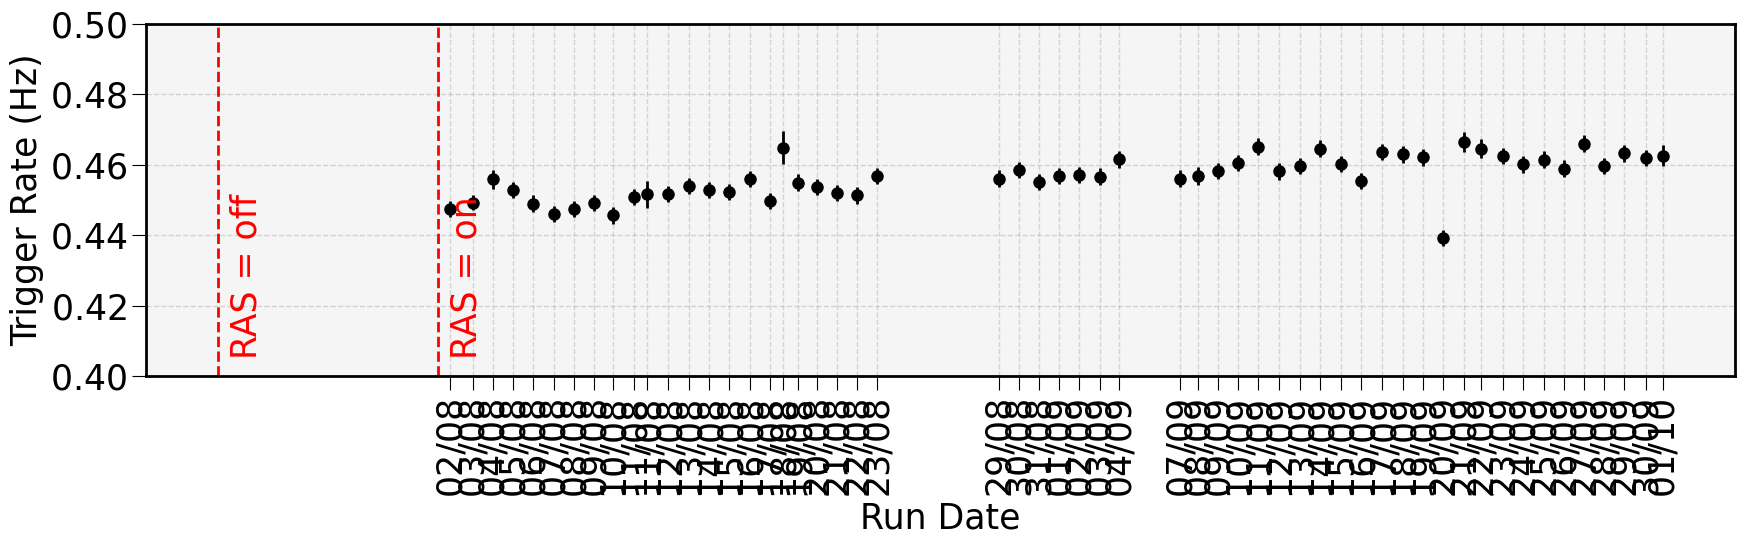

In [32]:
# Global
Date     = []
Date_err = []
Rate     = []
Rate_err = []
Run_numbers = []

for run_id in RATES_DF['Run_ID'].unique():

    # Skip some runs for plotting purposes
    if run_id in [15642]:
        continue
    
    # Run information
    duration = RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'Duration'].values[0]
    OK_trg   = RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'OK'].values[0]
    LOST_trg = RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'LOST'].values[0]
    Run_numbers.append(run_id)

    # Date + error for each run
    Date.append(RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'Date_CV'].values[0])
    Date_err.append(RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'Date_Err'].values[0])
    
    # Real rate + error for each run
    run_trigg = OK_trg + LOST_trg
    rate_CV   = run_trigg / duration
    Rate.append(rate_CV)
    rate_err = np.sqrt(run_trigg) / duration
    Rate_err.append(rate_err)

# ----- Plotting ---- #
fig, ax = plt.subplots(figsize=(18, 6))

# Data
plt.errorbar(Date, Rate, xerr=Date_err, yerr=Rate_err, fmt='o', c='black', ecolor='black')
# for x, y, run_id in zip(Date, Rate, Run_numbers):
#     plt.text(x, y, str(run_id), fontsize=8, ha='left', va='bottom', color='blue')       # Run number near the point

# Important dates
x_date = 5e4; y_date = 0.405
plt.axvline(x=CC_02, color='red', ls='--', lw=2.0)
plt.text(CC_02+x_date, y_date, 'RAS = off', color='red', ha='left', va='bottom', rotation=90)
plt.axvline(x=CC_RAS_02, color='red', ls='--', lw=2.0)
plt.text(CC_RAS_02+x_date, y_date, 'RAS = on', color='red', ha='left', va='bottom', rotation=90)

# ----- Styling ----- #
plt.xlabel('Run Date')
x_labels = [crudo.ut.epoch_converter(t, h=False) for t in Date]        # Convert x-axis bin edges to readable time format
plt.xticks(Date, x_labels, ha='center', rotation=90)
plt.ylabel('Trigger Rate (Hz)')
plt.ylim(0.4, 0.5)
# plt.ticklabel_format(axis='y', style='sci', scilimits=(-2, -2))
# plt.title('Trigger 02 Rate Evolution')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.tight_layout()
# plt.savefig(f'/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Trigger_Rate_Evolution.pdf')
plt.show()

# Reconstructed Rate

__UPDATE THIS!__

In [33]:
# Global
Date     = []
Date_err = []
Rate     = []
Rate_err = []
Run_numbers = []

for run_id, entry in runs_info.items():
    
    # Run information
    run_long = entry["duration"]
    run_OK   = entry["OK"]
    run_LOST = entry["LOST"]

    Run_numbers.append(run_id)

    # DAQe efficiency + error
    DAQe_CV, DAQe_error = ff.efficiency(run_OK, run_LOST)

    # Date + error for each run
    Date.append(EXTRA_INFO_DF.loc[run_id, 'Date_CV'])
    Date_err.append(EXTRA_INFO_DF.loc[run_id, 'Date_Err'])

    # Reco events
    reco_evts  = EXTRA_INFO_DF.loc[run_id, 'Reco_CV'];  reco_evts = int(reco_evts)
    reco_CV, reco_var = scipy.stats.binom.stats(n=runs_info[run_id]['OK'], p=reco_evts/runs_info[run_id]['OK'], moments='mv')
    
    # Reco rate + error for each run
    rate_CV  = reco_CV / (run_long * DAQe_CV)
    rate_err = rate_CV * np.sqrt((np.sqrt(reco_var) / reco_CV)**2 + (DAQe_error / DAQe_CV)**2)
    Rate.append(rate_CV)
    Rate_err.append(rate_err)                                  

# ----- Plotting ---- #
fig, ax = plt.subplots(figsize=(14, 6))

# Data
plt.errorbar(Date, Rate, xerr=Date_err, yerr=Rate_err, fmt='o', c='black', ecolor='black')
# for x, y, run_id in zip(Date, Rate, Run_numbers):
#     plt.text(x, y, str(run_id), fontsize=8, ha='left', va='bottom', color='blue')       # Run number near the point

# Important dates
x_date = 5e4; y_date = 0.421
plt.axvline(x=CC_02, color='red', ls='--', lw=2.0)
plt.text(CC_02+x_date, y_date, 'RAS = off', color='red', ha='left', va='bottom', rotation=90)
plt.axvline(x=CC_RAS_02, color='red', ls='--', lw=2.0)
plt.text(CC_RAS_02+x_date, y_date, 'RAS = on', color='red', ha='left', va='bottom', rotation=90)

# ----- Styling ----- #
plt.xlabel('Run Date')
x_labels = [crudo.ut.epoch_converter(t, h=False) for t in Date]        # Convert x-axis bin edges to readable time format
plt.xticks(Date, x_labels, ha='center', rotation=90)
plt.ylabel('Rate (Hz)')
plt.ylim(0.42, 0.48)
# plt.legend(loc='upper right', fontsize=9)
plt.title('Reconstructed Events')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

NameError: name 'runs_info' is not defined

# Fiducial Rate

In [81]:
# Global
Date     = []
Date_err = []
Rate     = []
Rate_err = []
Run_numbers = []

FIDUCIAL_EFF_STD = 6.3e-3       # Standard fiducial efficiency for correction

def const_func(x, a):
    return crudo.ff.linear_func(x, 0, a)

for run_id in RATES_DF['Run_ID'].unique():

    print(f'Processing Run {run_id}:')

    # --- Skip some runs for plotting purposes
    if run_id in [15642]:
        continue
    
    # Run information
    duration = RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'Duration'].values[0]
    OK_trg   = RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'OK'].values[0]
    LOST_trg = RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'LOST'].values[0]
    # DAQe efficiency + error
    DAQe_CV, DAQe_error = crudo.ff.efficiency(OK_trg, LOST_trg)
    Run_numbers.append(run_id)

    # Date + error for each run
    date_cv = RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'Date_CV'].values[0]

    # # --- Skip runs after Sep 2025: if you need it
    # if date_cv > SEP_2025:
    #     continue
    
    Date.append(date_cv)
    Date_err.append(RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'Date_Err'].values[0])

    # Fiducial events
    fidu_evts  = RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'Fiducial'].values[0];    fidu_evts = int(fidu_evts)
    fidu_CV, fidu_var = scipy.stats.binom.stats(n=OK_trg, p=fidu_evts/OK_trg, moments='mv')
    print(f'  Fiducial Events = {fidu_CV:.2f}, Var = {fidu_var:.2f}, Duration = {duration} s, DAQe = {DAQe_CV:.4f} ± {DAQe_error:.4f}')

    # ----- Rate Correction ----- #
    if run_id in [15655, 15656, 15657, 15658, 15659]:
        
        eff_fid, eff_err = crudo.ff.efficiency(fidu_CV, OK_trg - fidu_CV)    # Fiducial efficiency + error
        corr_factor = FIDUCIAL_EFF_STD / eff_fid
        print(f'  Correction Factor = {corr_factor:.4f} | Fiducial Eff = {eff_fid:.4f} ± {eff_err:.4f}')

    else:
        corr_factor = 1.0

    fidu_CV  *= corr_factor
    fidu_var *= corr_factor**2
    
    # Fiducial rate + error for each run
    rate_CV  = fidu_CV / (duration * DAQe_CV)
    rate_err = rate_CV * np.sqrt((np.sqrt(fidu_var) / fidu_CV)**2 + (DAQe_error / DAQe_CV)**2)
    Rate.append(rate_CV*1e3)        # In [mHz]
    Rate_err.append(rate_err*1e3)
    print(f'  Rate = {rate_CV*1e3:.4f} ± {rate_err*1e3:.4f} mHz\n')

Processing Run 15625:
  Fiducial Events = 236.00, Var = 234.17, Duration = 87329 s, DAQe = 0.7806 ± 0.0021
  Rate = 3.4618 ± 0.2247 mHz

Processing Run 15626:
  Fiducial Events = 292.00, Var = 289.74, Duration = 107092 s, DAQe = 0.7829 ± 0.0019
  Rate = 3.4828 ± 0.2032 mHz

Processing Run 15627:
  Fiducial Events = 148.00, Var = 147.00, Duration = 61872 s, DAQe = 0.7788 ± 0.0025
  Rate = 3.0713 ± 0.2518 mHz

Processing Run 15632:
  Fiducial Events = 224.00, Var = 222.35, Duration = 86709 s, DAQe = 0.7752 ± 0.0021
  Rate = 3.3323 ± 0.2220 mHz

Processing Run 15633:
  Fiducial Events = 196.00, Var = 194.72, Duration = 86076 s, DAQe = 0.7780 ± 0.0021
  Rate = 2.9266 ± 0.2085 mHz

Processing Run 15634:
  Fiducial Events = 197.00, Var = 195.72, Duration = 86545 s, DAQe = 0.7867 ± 0.0021
  Rate = 2.8934 ± 0.2056 mHz

Processing Run 15635:
  Fiducial Events = 196.00, Var = 194.75, Duration = 87672 s, DAQe = 0.7824 ± 0.0021
  Rate = 2.8573 ± 0.2036 mHz

Processing Run 15636:
  Fiducial Events 

In [82]:
# Global
PERIODS = ['RAS off', 'RAS on']        # Options: 'RAS off', 'RAS on'
X_FIT = []
Y_FIT = []

# ----- Linear Fits ----- #
# Preliminary
Date     = np.array(Date)
Date_err = np.array(Date_err)
Rate     = np.array(Rate)
Rate_err = np.array(Rate_err)

for i, period in enumerate(PERIODS):

       if period == 'RAS off':
              print(f"--- Fitting Period: Castle = closed & RAS = off ---")
              # Masking: select specific data
              masking_time = (Date >= CC_02) & (Date < CC_RAS_02)
       elif period == 'RAS on':
              print(f"--- Fitting Period: Castle = closed & RAS = on ---")
              # Masking: select specific data
              masking_time = (Date >= CC_RAS_02)       # Just fit data for purest conditions

       x_data = Date[masking_time]
       y_data = Rate[masking_time]
       y_err  = Rate_err[masking_time]

       if x_data.size == 0:
              print(f"No data points available for period '{period}'. Saving null arrays.\n")
              X_FIT.append(None)  # In [s]
              Y_FIT.append(None)
              continue

       # Shifted time
       x_shift = (x_data - x_data[0]) / 3600   # In [hr] for numeric stability

       # Define the cost function + initial guess
       least_squares = LeastSquares(x_shift, y_data, y_err, const_func)
       init_guess = [y_data.min()]

       # Define the Minuit object
       m = Minuit(least_squares, *init_guess)

       # Minimization process of the cost function and error estimation
       m.migrad()
       m.hesse()

       # Results
       popt = m.values;  perr = m.errors
       print(f"Rate of Fiducial Background: ({popt[0]:.2f} ± {perr[0]:.2f}) mHz")

       # Reduced chi-square
       chi2 = m.fval
       ndof = len(x_shift) - m.nfit
       p_value = scipy.stats.chi2.sf(chi2, ndof)
       print(f"χ² / ndof = {chi2 / ndof:.2f}\n"
              f"p-value = {p_value:.2f}\n")

       # Fits
       X_FIT.append((x_shift * 3600) + x_data[0])  # In [s]
       Y_FIT.append(const_func(x_shift, *popt))

--- Fitting Period: Castle = closed & RAS = off ---
No data points available for period 'RAS off'. Saving null arrays.

--- Fitting Period: Castle = closed & RAS = on ---
Rate of Fiducial Background: (3.13 ± 0.03) mHz
χ² / ndof = 1.15
p-value = 0.21



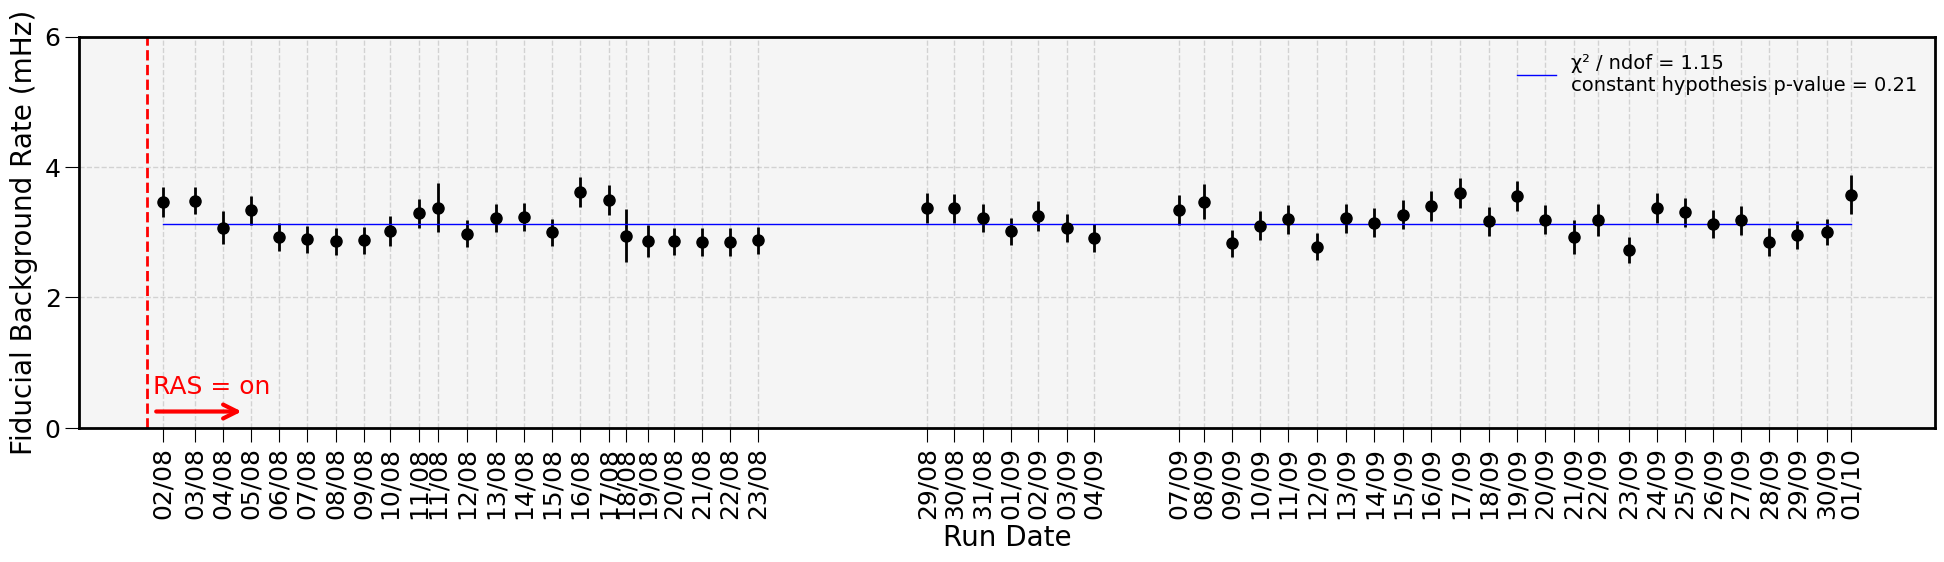

In [89]:
# ----- Plotting ---- #
fig, ax = plt.subplots(figsize=(20, 6))

# Data
plt.errorbar(Date, Rate, xerr=Date_err, yerr=Rate_err, fmt='o', c='black', ecolor='black')
# for x, y, run_id in zip(Date, Rate, Run_numbers):
#     plt.text(x, y, str(run_id), fontsize=8, ha='left', va='bottom', color='blue')       # Run number near the point

# Fits
# plt.plot(X_FIT[0], Y_FIT[0], color='green', ls='-', label=f'RAS = off')
plt.plot(X_FIT[1], Y_FIT[1], color='blue', ls='-', lw=1.0, label=f'χ² / ndof = {chi2 / ndof:.2f}\nconstant hypothesis p-value = {p_value:.2f}')

# Important dates
x_date = 2e4; y_date = 0.25
# plt.axvline(x=CC_02, color='red', ls ='--')
# plt.text(CC_02+x_date, y_date, 'RAS = off', color='red', ha='left', va='bottom', rotation=90)
plt.axvline(x=CC_RAS_02, color='red', ls ='--')
ax.annotate('', xytext=(CC_RAS_02+x_date, y_date), xy=(CC_RAS_02+15*x_date, y_date), arrowprops=dict(arrowstyle='->',  ec='red', fc='red'))
plt.text(CC_RAS_02+x_date, 1.8*y_date, 'RAS = on', c='red', ha='left', va='bottom', fontsize=18)

# ----- Styling ----- # 
# Preliminary logo
# LOGO_BOX    = OffsetImage(PRELIM_LOGO, zoom = 0.1)
# xy = (Date.max(), Rate.max())
# ab = AnnotationBbox(LOGO_BOX, xy, xybox=(-50, 40), xycoords='data', boxcoords="offset points",  frameon=False)
# ax.add_artist(ab)

plt.xlabel('Run Date', fontsize=20)
x_labels = [crudo.ut.epoch_converter(t, h=False) for t in Date]        # Convert x-axis bin edges to readable time format
plt.xticks(Date, x_labels, ha='center', rotation=90)
plt.xticks(fontsize=18)
plt.ylabel('Fiducial Background Rate (mHz)', fontsize=20)
plt.yticks(fontsize=18)
plt.ylim(0, 6)
plt.legend(loc='upper right', fontsize=14, facecolor='none')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig(f'/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Fiducial_Rate_Evolution.pdf')
plt.tight_layout()
plt.show()

# Efficiencies

La parte global y relativa hay que actualizar, esto es _outdated_

In [9]:
# PERFORMED_CUTS = ['Reco_CV', 'After_Zneg', 'nS1_0', 'nS1_1', 'nS1_NOPolike', 'After_S1', 'After_S2', 'nElectron', 'Clean_nElectron', 'nElectron_Trg2', 'nElectron_Fiducial']
PERFORMED_CUTS = ['Reco_CV', 'After_Zneg', 'After_S1', 'After_S2', 'nElectron', 'Clean_nElectron', 'nElectron_Trg2', 'nElectron_Fiducial']

CUTS_VERBOSITY = [
                    'IC reconstruction', 
                    'Z negative removal', 
                    'S1 ≤ 1', 
                    'S2 = 1', 
                    'E ≤ 3 MeV', 
                    'Cleaning spurious hits', 
                    'E ≥ 0.5 MeV (Trigger 2)', 
                    'Fiducial selection'
                ]

### Global

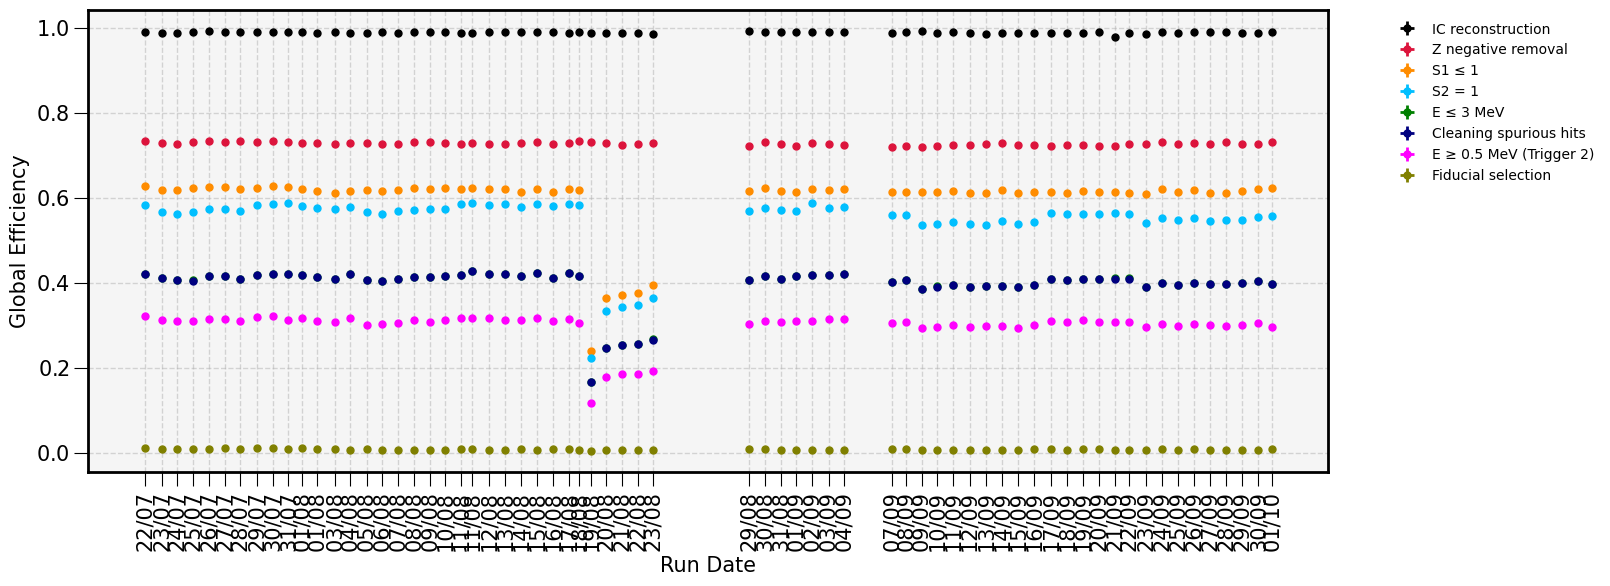

In [11]:
# Global
fig, ax = plt.subplots(figsize=(16, 6))

for i, cut in enumerate(PERFORMED_CUTS):

    # Storage
    Date_CV = [];      Date_Err = []
    Cut_CV  = [];      Cut_Err  = []

    Run_numbers = []

    for run_id, entry in runs_info.items():

        # Run information
        run_long = entry["duration"]
        run_OK   = entry["OK"]
        run_LOST = entry["LOST"]

        Run_numbers.append(run_id)

        # Date + error for each run
        Date_CV.append(EXTRA_INFO_DF.loc[run_id, 'Date_CV'])
        Date_Err.append(EXTRA_INFO_DF.loc[run_id, 'Date_Err'])

        # Global efficiency
        after_cut_evts = EXTRA_INFO_DF.loc[run_id, cut]
        after_cut_CV, after_cut_error = ff.efficiency(after_cut_evts, run_OK - after_cut_evts)
        Cut_CV.append(after_cut_CV);  
        Cut_Err.append(after_cut_error)

    # ----- Plotting ----- #
    # Data
    plt.errorbar(Date_CV, Cut_CV, xerr=Date_Err, yerr=Cut_Err, 
                 fmt='o', ms=5, c=pt.hist_colors[i % len(pt.hist_colors)], 
                 ecolor=pt.hist_colors[i % len(pt.hist_colors)], label=CUTS_VERBOSITY[i])
    
    # if i == 0:
    #     for x, y, run_id in zip(Date_CV, Cut_CV, Run_numbers):
    #         plt.text(x, 1.005*max(Cut_CV), str(run_id), fontsize=8, ha='center', va='bottom', color='blue')       # Run number near the point
    # else:
    #     continue

    # Xticks
    x_labels = [crudo.epoch_converter(t, h=False) for t in Date_CV]        # Convert x-axis bin edges to readable time format
    plt.xticks(Date_CV, x_labels, ha='center', rotation=90)

# ----- Styling ----- #
plt.xlabel('Run Date')
plt.ylabel('Global Efficiency')
# plt.ylim(0.4, 0.42)
plt.legend(loc='upper right', bbox_to_anchor=(1.225, 1), fontsize=10)

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

### Relative

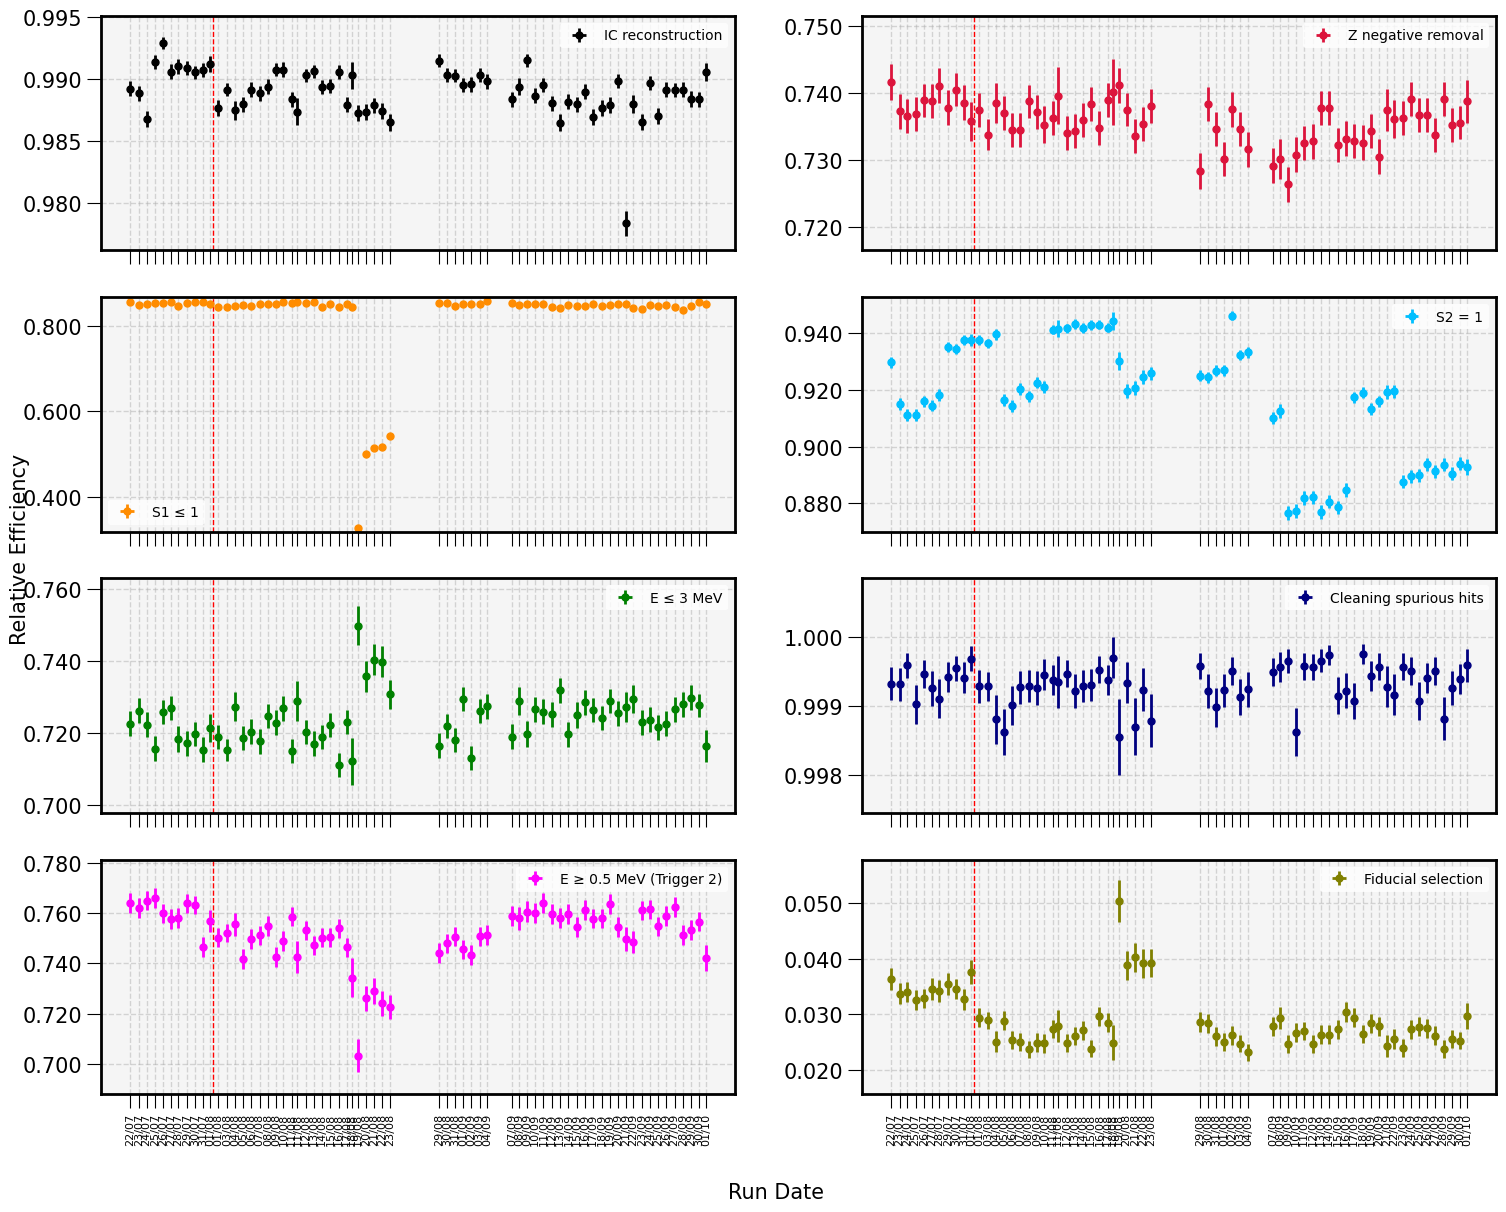

In [12]:
# Global
fig, ax = plt.subplots(nrows=4, ncols=2, sharex=True, figsize=(18, 14))

for i, cut in enumerate(PERFORMED_CUTS):

    # Storage
    Date_CV = [];      Date_Err = []
    Cut_CV  = [];      Cut_Err  = []

    Run_numbers = []

    for run_id, entry in runs_info.items():

        # Run information
        run_long = entry["duration"]
        run_OK   = entry["OK"]
        run_LOST = entry["LOST"]

        Run_numbers.append(run_id)

        # Date + error for each run
        Date_CV.append(EXTRA_INFO_DF.loc[run_id, 'Date_CV'])
        Date_Err.append(EXTRA_INFO_DF.loc[run_id, 'Date_Err'])

        # Global efficiency
        if i == 0:
            before_cut_evts = run_OK
        else:
            before_cut_evts = EXTRA_INFO_DF.loc[run_id, PERFORMED_CUTS[i-1]]

        after_cut_evts  = EXTRA_INFO_DF.loc[run_id, cut]
        after_cut_CV, after_cut_error = ff.efficiency(after_cut_evts, before_cut_evts - after_cut_evts)
        Cut_CV.append(after_cut_CV);  
        Cut_Err.append(after_cut_error)

    # ----- Plotting ----- #
    # Data
    ax[i//2, i%2].errorbar(Date_CV, Cut_CV, xerr=Date_Err, yerr=Cut_Err, 
                 fmt='o', ms=5, c=pt.hist_colors[i % len(pt.hist_colors)], 
                 ecolor=pt.hist_colors[i % len(pt.hist_colors)], label=CUTS_VERBOSITY[i])
    
    # Important dates
    ax[i//2, i%2].axvline(x=CC_RAS_02, color='red', ls ='--', lw=1.0)       # RAS = on

    # ----- Styling ----- #
    x_labels = [crudo.epoch_converter(t, h=False) for t in Date_CV]         # Convert x-axis bin edges to readable time format
    ax[i//2, i%2].set_xticks(Date_CV)
    ax[i//2, i%2].set_xticklabels(x_labels, ha='center', rotation=90, fontsize=8)
    min_y = min(Cut_CV) - (2 * np.max(Cut_Err));  max_y = max(Cut_CV) + (2 * np.max(Cut_Err))
    # if cut == 'After_S1':
    #     min_y = min(Cut_CV)-2*np.max(Cut_Err);  max_y = max(Cut_CV)+2*np.max(Cut_Err)
    #     # min_y = min(Cut_CV) - 0.05;  max_y = max(Cut_CV) + 0.05
    # else:
    #     min_y = min(Cut_CV)-2*np.max(Cut_Err);  max_y = max(Cut_CV)+2*np.max(Cut_Err)
    ax[i//2, i%2].set_ylim(min_y, max_y)
    ax[i//2, i%2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
    ax[i//2, i%2].legend(loc='best', fontsize=10)

    ax[i//2, i%2].grid(True)
    ax[i//2, i%2].set_facecolor("whitesmoke")

fig.text(0.5, 0.04, 'Run Date', ha='center', va='center', fontsize=15)
fig.text(0.08, 0.5, 'Relative Efficiency', ha='center', va='center', rotation=90, fontsize=15)
plt.show()

## Fiducial Cut

There were some runs with affectation in their $S1$ cut efficiency, namely:
- 15655, 15656, 15657, 15658, 15659
<!-- end of the list -->
We re-escale their fiducial rate by the difference with the "usual" fiducial cut efficiency.

In [ ]:
# Storage
Date_CV = [];      Date_Err = []
Eff_CV  = [];      Eff_Err  = []
Run_numbers = []

CUT_INTEREST = 'nElectron_Fiducial'     # For example: 'S1_Cut'

for run_id in RATES_DF['Run_ID'].unique():

    # Skip baddies
    if run_id in [15655, 15656, 15657, 15658, 15659]:
        continue

    # Run information
    duration = RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'Duration'].values[0]
    OK_trg   = RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'OK'].values[0]
    LOST_trg = RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'LOST'].values[0]
    Run_numbers.append(run_id)

    # Date + error for each run
    date_CV = RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'Date_CV'].values[0]

    # Just use RAS = on period
    if date_CV < CC_RAS_02:
        continue
    
    Date_CV.append(date_CV)
    Date_Err.append(RATES_DF.loc[RATES_DF['Run_ID'] == run_id, 'Date_Err'].values[0])

    # Global efficiency
    events_of_interest = RATES_DF.loc[RATES_DF['Run_ID'] == run_id, CUT_INTEREST].values[0];    events_of_interest = int(events_of_interest)
    after_cut_CV, after_cut_error = ff.efficiency(events_of_interest, OK_trg - events_of_interest)
    Eff_CV.append(after_cut_CV);  
    Eff_Err.append(after_cut_error)

In [10]:
# ----- Constant Fit ----- #
def const_func(x, b):
    return ff.linear_func(x, 0, b)

# Preliminary
Date_CV  = np.array(Date_CV)
Date_Err = np.array(Date_Err)
Eff_CV   = np.array(Eff_CV)
Eff_Err  = np.array(Eff_Err)

# Define the cost function
least_squares = LeastSquares(Date_CV, Eff_CV, Eff_Err, const_func)

# Define the Minuit object with inital guesses for the parameters
m = Minuit(least_squares, b=0)

# Minimization process of the cost function and error estimation
m.migrad()
m.hesse()

# Reduced chi-square
chi2 = m.fval
ndof = len(Date_CV) - m.nfit
p_value = scipy.stats.chi2.sf(chi2, ndof)

print (f"Fit results: b = {m.values['b']:.4f} ± {m.errors['b']:.4f}\n"
       f" χ² / ndof = {chi2:.2f} / {ndof:.2f} = {chi2 / ndof:.2f}\n"
       f" p-value = {p_value:.4f}")

Fit results: b = 0.0063 ± 0.0001
 χ² / ndof = 51.12 / 50.00 = 1.02
 p-value = 0.4296


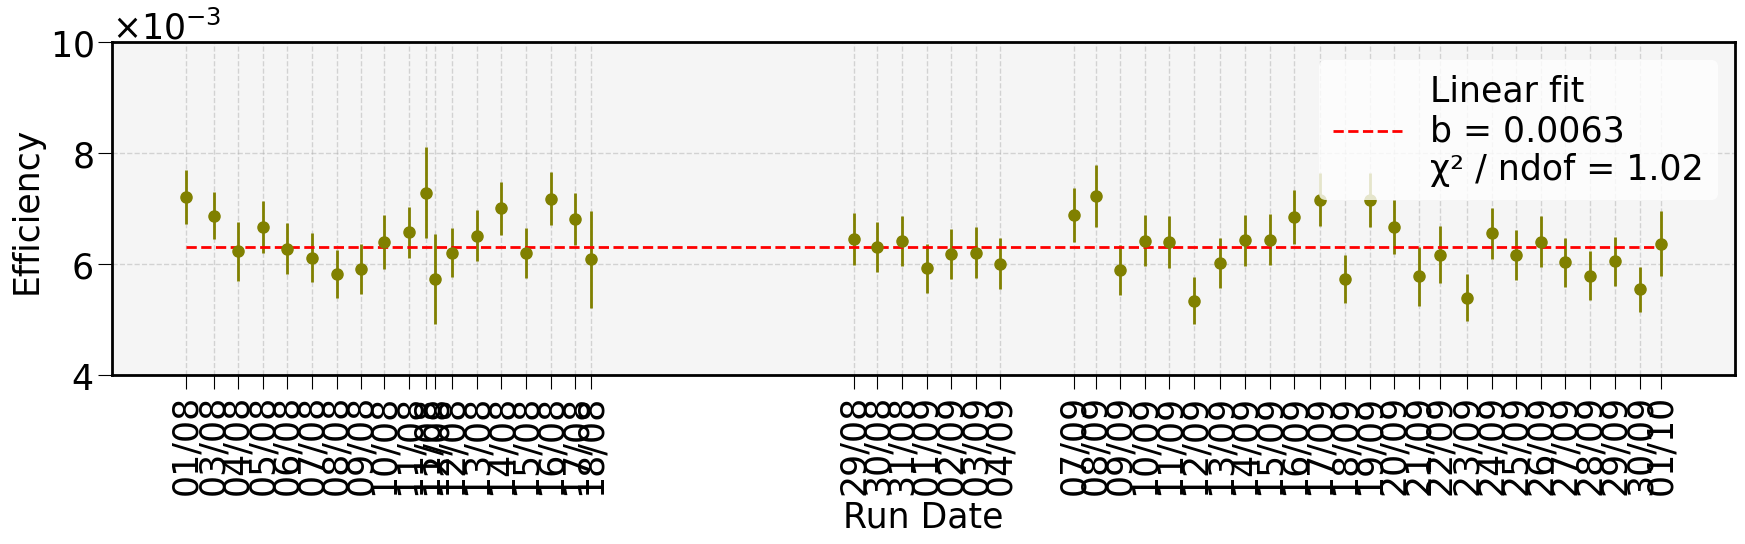

In [15]:
# ----- Plotting ----- #
fig, ax = plt.subplots(figsize=(18, 6))
# Data
plt.errorbar(Date_CV, Eff_CV, xerr=Date_Err, yerr=Eff_Err, fmt='o', c=pt.hist_colors[7], ecolor=pt.hist_colors[7])
# for x, y, run_id in zip(Date_CV, Eff_CV, Run_numbers):
#     plt.text(x, 1.005*max(Eff_CV), str(run_id), fontsize=8, ha='center', va='bottom', color='blue')       # Run number near the point

# Fit
y_fit = const_func(Date_CV, m.values['b'])
plt.plot(Date_CV, y_fit, color='red', ls='--', lw=2.0, label=f"Linear fit\nb = {m.values['b']:.4f}\nχ² / ndof = {chi2 / ndof:.2f}")

# ----- Styling ----- #
plt.xlabel('Run Date')
x_labels = [crudo.epoch_converter(t, h=False) for t in Date_CV]        # Convert x-axis bin edges to readable time format
plt.xticks(Date_CV, x_labels, ha='center', rotation=90)
plt.ylabel('Efficiency')
plt.ylim(4e-3, 10e-3)
plt.ticklabel_format(axis='y', style='sci', scilimits=(-3, -3))
plt.legend(loc='upper right')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.tight_layout()
plt.show()